In [1]:
import time
from functools import partial
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# Set a random seed for reproducibility
key = jax.random.PRNGKey(42)

## Problem Overview: 1D Ordinary Differential Equation

We are using a Physics-Informed Neural Network (PINN) to solve the following first-order ordinary differential equation:

$$\frac{dy}{dx} = x$$

### Domain and Conditions
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Exact Solution
The analytical solution for this specific problem is:
$$y(x) = \frac{x^2}{2}$$

In [2]:
def exact_solution(x):
    return (x**2)/2

def plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch):
    test_error = jnp.mean(jnp.abs(y_test_batch - y_exact_batch) / y_exact_batch.std())
    plt.figure(figsize=(8,3))
    plt.scatter(x_physics_batch[:,0], jnp.zeros_like(x_physics_batch)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
    plt.scatter(x_boundary, 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point (x=0)")
    plt.plot(x_test_batch[:,0], y_exact_batch[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x_test_batch[:,0], y_test_batch[:,0], label="PINN solution", color="tab:green")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Step {i} | Relative L1 Error: {test_error:.2%}")
    plt.legend()
    plt.show()

In [3]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [4]:
def get_hard_embedded_y(parameters, x_val, network):
    # Boundary values at x=1: y(1)=3, y'(1)=-4
    u0 = 0
    t = x_val - 0.0  # Shifted coordinate to make x=1 act like t=0

    # NN output for the 'correction' part
    # We reshape and squeeze to ensure scalar compatibility for jax.grad
    nn_output = network.forward(parameters, x_val.reshape(1,)).squeeze()

    # Trial form: y = y0 + v0*t + t^2 * NN(t)
    return u0 + (nn_output * t)

def PINN_physics_loss(parameters, x, network):
    """Residual: y' - x = 0"""
    x_val = x.squeeze()

    # Compute y and its derivatives using the hard-embedded form
    y = get_hard_embedded_y(parameters, x_val, network)
    dydx = jax.grad(get_hard_embedded_y, argnums=1)(parameters, x_val, network)

    # Residual calculation: y'-x = 0
    residual = dydx - x_val
    return residual**2

def PINN_loss_batch(parameters, x_boundary, x_physics_batch, network):
    # Only the physics loss is needed now
    loss_physics_batch = jax.vmap(PINN_physics_loss, in_axes=(None, 0, None))(parameters, x_physics_batch, network)
    return jnp.mean(loss_physics_batch)

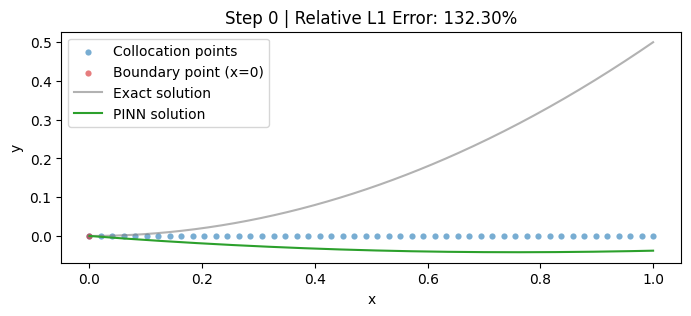

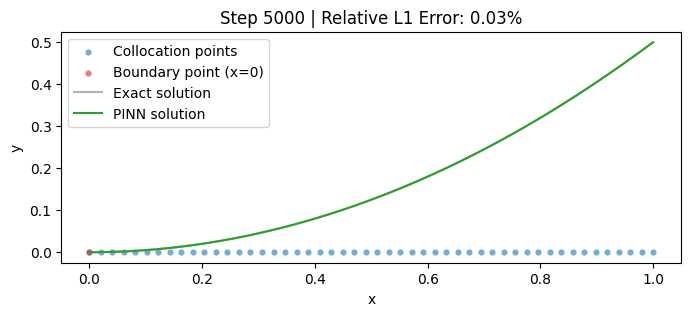

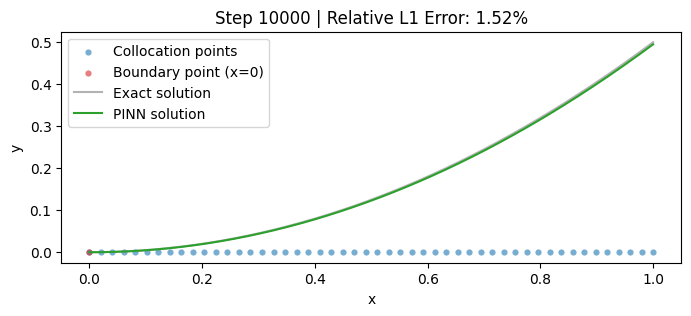

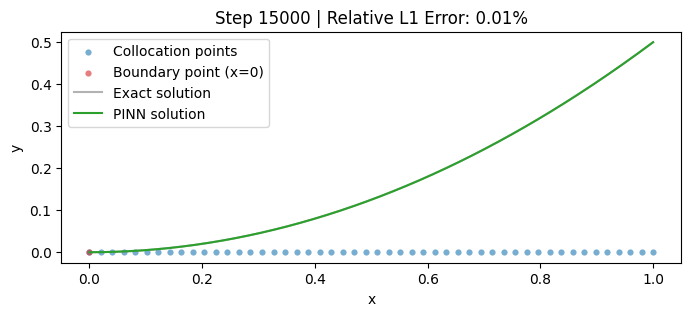

In [5]:
@partial(jax.jit, static_argnums=(1, 5))
def PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network):
    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        parameters, x_boundary, x_physics_batch, network)
    updates, opt_state = optimiser.update(grads, opt_state, parameters)
    parameters = optax.apply_updates(parameters, updates)
    return loss, opt_state, parameters

# Setup and Execution
x_boundary = jnp.array([0.0])
x_physics_batch = jnp.linspace(0, 1, 50).reshape(-1, 1)
x_test_batch = jnp.linspace(0, 1, 300).reshape(-1, 1)
y_exact_batch = jax.vmap(exact_solution)(x_test_batch)

network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(parameters)

for i in range(15001):
    loss, opt_state, parameters = PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network)
    if i % 5000 == 0:
        # Use vmap to apply the hard-embedded trial form across all test points
        y_test_batch = jax.vmap(get_hard_embedded_y, in_axes=(None, 0, None))(parameters, x_test_batch, network)
        plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch)

## Inverse Problem Overview: Parameter Estimation

In an *inverse problem*, instead of solving for the state of the system given known parameters, we use observed data to infer unknown parameters of the system. Here, we aim to estimate an unknown parameter (which we'll call `alpha`) in our ODE $\frac{dy}{dx} = \alpha x$, given some noisy measurements of $y(x)$.

### Problem Statement
- **Governing Equation**: $\frac{dy}{dx} = \alpha x$
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Goal
Infer the value of $\alpha$ using observed data, knowing that the true value of $\alpha$ is $1.0$ (leading to the exact solution $y(x) = \frac{x^2}{2}$).

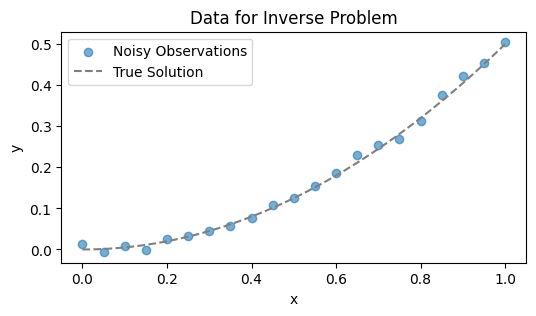

In [13]:
import pandas as pd

# 1. Define the updated exact solution for data generation
def exact_solution(x):
    return (x**2)/2

# 2. Generate noisy observational data
key, subkey = jax.random.split(key);
# User-provided data
data = {
    't': [0, 0.0500, 0.1000, 0.1500, 0.2000, 0.2500, 0.3000, 0.3500, 0.4000, 0.4500, 0.5000, 0.5500, 0.6000, 0.6500, 0.7000, 0.7500, 0.8000, 0.8500, 0.9000, 0.9500, 1.0000],
    'y(t)': [0, 0.0013, 0.0050, 0.0112, 0.0200, 0.0312, 0.0450, 0.0613, 0.0800, 0.1013, 0.1250, 0.1513, 0.1800, 0.2112, 0.2450, 0.2813, 0.3200, 0.3613, 0.4050, 0.4513, 0.5000]
}
df_obs = pd.DataFrame(data)

x_obs = jnp.array(df_obs['t'].values, dtype=jnp.float32).reshape(-1, 1)
y_obs = jnp.array(df_obs['y(t)'].values, dtype=jnp.float32).reshape(-1, 1) + 0.01 * jax.random.normal(subkey, (len(df_obs), 1))

# Visualize the data the PINN will learn from
plt.figure(figsize=(6, 3))
plt.scatter(x_obs, y_obs, label="Noisy Observations", color="tab:blue", alpha=0.6)
x_plot = jnp.linspace(0, 1, 100)
plt.plot(x_plot, exact_solution(x_plot), label="True Solution", color="grey", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Data for Inverse Problem")
plt.show()

Step 0 | Loss: 8.3963e-02 | Alpha Estimate: 0.0010
Step 1000 | Loss: 3.7020e-03 | Alpha Estimate: 0.7155
Step 2000 | Loss: 1.0781e-04 | Alpha Estimate: 0.9849
Step 3000 | Loss: 6.5911e-05 | Alpha Estimate: 1.0158
Step 4000 | Loss: 6.5825e-05 | Alpha Estimate: 1.0163
Step 5000 | Loss: 6.5766e-05 | Alpha Estimate: 1.0163
Step 6000 | Loss: 6.5759e-05 | Alpha Estimate: 1.0163
Step 7000 | Loss: 6.5729e-05 | Alpha Estimate: 1.0163
Step 8000 | Loss: 6.5642e-05 | Alpha Estimate: 1.0164
Step 9000 | Loss: 6.5621e-05 | Alpha Estimate: 1.0164
Step 10000 | Loss: 6.5640e-05 | Alpha Estimate: 1.0163
Step 11000 | Loss: 6.5601e-05 | Alpha Estimate: 1.0164
Step 12000 | Loss: 7.1059e-05 | Alpha Estimate: 1.0163
Step 13000 | Loss: 6.5596e-05 | Alpha Estimate: 1.0164
Step 14000 | Loss: 6.6644e-05 | Alpha Estimate: 1.0164
Step 15000 | Loss: 7.4324e-05 | Alpha Estimate: 1.0165


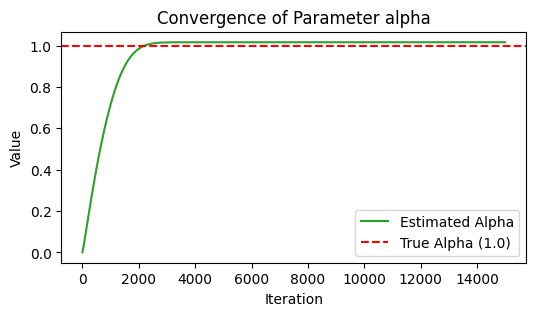

In [14]:
# 1. Define Physics Loss with unknown alpha
def PINN_inverse_physics_loss(parameters, alpha, x, network):
    x_val = x.squeeze()

    # Compute y and its derivatives via the hard-embedded form
    y = get_hard_embedded_y(parameters, x_val, network)
    dydx = jax.grad(get_hard_embedded_y, argnums=1)(parameters, x_val, network)

    # Physics residual: y'-x = 0
    residual = dydx - (alpha) * x_val
    return residual**2

# 2. Define Total Batch Loss (Physics + Data)
def PINN_inverse_loss_batch(params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    parameters, alpha = params_and_alpha

    # Vectorize physics loss
    loss_physics = jnp.mean(jax.vmap(PINN_inverse_physics_loss, in_axes=(None, None, 0, None))(
        parameters, alpha, x_physics_batch, network))

    # Data loss: match observations using the trial form
    y_pred_obs = jax.vmap(get_hard_embedded_y, in_axes=(None, 0, None))(parameters, x_obs, network)
    loss_data = jnp.mean((y_pred_obs - y_obs)**2)

    return loss_physics + 1e0 * loss_data

# 3. Define JIT-compiled Step Function
@partial(jax.jit, static_argnums=(1, 6)) # Corrected: optimiser is at 1, network is at 6
def inverse_step(opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    """Updates PINN parameters and the unknown alpha using the optax optimiser"""

    # get loss and gradient over the combined parameters (network weights + alpha)
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=0)(
        params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    # apply parameter update
    updates, opt_state = optimiser.update(grads, opt_state, params_and_alpha)
    params_and_alpha = optax.apply_updates(params_and_alpha, updates)

    return loss, opt_state, params_and_alpha

# 4. Initialize and Run Training
network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
alpha_init = jnp.array(0.0) # Initial guess
params_and_alpha = (parameters, alpha_init)

optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(params_and_alpha)

alphas = []
for i in range(15001):
    loss, opt_state, params_and_alpha = inverse_step(
        opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    current_alpha = params_and_alpha[1]
    alphas.append(current_alpha)

    if i % 1000 == 0:
        # Use vmap to apply the hard-embedded trial form for plotting
        y_test_pred = jax.vmap(get_hard_embedded_y, in_axes=(None, 0, None))(
            params_and_alpha[0], x_test_batch, network)
        print(f"Step {i} | Loss: {loss:.4e} | Alpha Estimate: {current_alpha:.4f}")

# Plot convergence
plt.figure(figsize=(6, 3))
plt.plot(alphas, label="Estimated Alpha", color="tab:green")
plt.axhline(y=1.0, color="red", linestyle="--", label="True Alpha (1.0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.title("Convergence of Parameter alpha")
plt.show()

| Number of Points | Final Estimated Alpha | Error |
|------------------|-----------------------|-------|
| 21 | 1.0165 | 0.0165 |
| 11 | 0.9753 | 0.0247 |
| 6 | 1.0880 | 0.0880 |
| 3 | 0.9562 | 0.0438 |

note: 0.01 noise used for 21pts while 0.02 for others